# Testing Mediapipe Methods


# Attempt 1:
Here I tried detecting the face using Mediapipe, using the middle points to rotate the face to be vertical and then running Mediapipe on the rotated face again but the rotation blurs the image and so mediapipe cannot always detect the new face and if it does detect the new face the landmarks may not be as accurate as before

In [83]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
# from mediapipe.tasks.python.vision import drawing_utils
#from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Visualisation tools

In [84]:
mp_drawing = mp.solutions.drawing_utils

from pathlib import Path

model_path = Path("face_landmarker.task")

print(model_path.resolve())
print(model_path.exists())



/Users/evedurant/Desktop/facemetric-api/models/face_landmarker.task
True


### Code adapted from MediaPipe Face Landmarker example:

In [85]:
# Create a FaceLandmarker object

# Code adapted from google Mediapipe Face Landmarker example:

# this dewscribes where the trained model is stored
base_options = python.BaseOptions(model_asset_path=str(model_path))

# this configures how the face landmarker should behave
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
# detector uses options from above
detector = vision.FaceLandmarker.create_from_options(options)



I0000 00:00:1786457377.967250 2297142 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 83), renderer: Apple M2
W0000 00:00:1786457377.978629 2297142 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


In [86]:
import cv2 as cv
import numpy as np


def draw_landmarks(rgb_image: np.ndarray, detection_result, radius=3) -> np.ndarray:
    """
    Draws a bunch of dots around the face showing facial contours
    
    rgb_image: Input image represented as a NumPy array (height, width, channels).

    detection_result: this is the facial detection output with normalised landmark coordinates
    
    """

    # this makes sure original input isnt modified
    annotated_image = rgb_image.copy()
    height, width, _ = annotated_image.shape


    if not detection_result.face_landmarks:
        return annotated_image

    # selects first detected face
    first_face = detection_result.face_landmarks[0]
    

    # topmost_landmark = min(
    #     enumerate(first_face),
    #     key=lambda item: item[1].y,
    # )
    
    # index, landmark = topmost_landmark
    
    # iterate through every detected face
    for face_landmarks in detection_result.face_landmarks:

        # iterate through every landmark
        for landmark in face_landmarks:

            # multiply normalised coordinates by width and height to get pixel coordinates that 
            # match the image
            x = int(landmark.x * width)
            y = int(landmark.y * height)

            # draw a circle for each coordinate
            cv.circle(
                annotated_image,
                (x, y),
                radius=radius,
                color=(0, 0, 0),
                thickness=-1,
            )

    return annotated_image





In [87]:
def print_annotated_img(img_path, radius=3):
    # make image
    bgr_image = cv.imread(img_path)

    if bgr_image is None:
        raise FileNotFoundError( f"opencv cant read image")

    rgb_image = cv.cvtColor(
        bgr_image,
        cv.COLOR_BGR2RGB,
    )

    rgb_image = np.ascontiguousarray(
        rgb_image,
        dtype=np.uint8,
    )

    # create mediapipe image object
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image, )

    # detect landmarks 
    detection_result = detector.detect(mp_image)
    
   

    
    annotated_image = draw_landmarks( 
        rgb_image,
        detection_result, radius
    )
    return annotated_image



/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


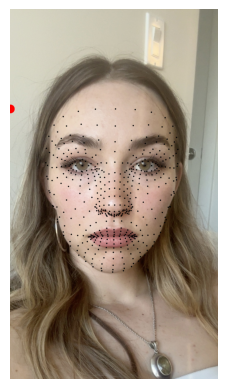

In [196]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/face.jpg"




annotated_img = print_annotated_img(img_path )

cv.circle(
    annotated_img,
    (1, 456),
    radius=20,
    color=(255, 0, 0),
    thickness=-1,
            )


plt.imshow(annotated_img)

plt.axis("off")
plt.show()  

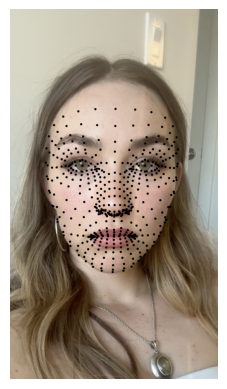

In [90]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/face.jpg"

annotated_img = print_annotated_img(img_path, 5)
plt.imshow(annotated_img)
plt.axis("off")
plt.show()  

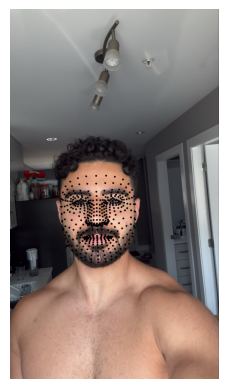

In [91]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/sina.jpg"

annotated_img = print_annotated_img(img_path, 5)
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [92]:
EYE_INDICES = {
    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "right_eye_inner": 362,
    "right_eye_outer": 263,
}

NOSE_INDICES = {
    "nose_tip": 1,
    "nose_left": 98,
    "nose_right": 327,
}

MOUTH_INDICES = {
    "mouth_left": 61,
    "mouth_right": 291,
    "upper_lip": 13,
    "lower_lip": 14,
}

FACE_INDICES = {
    "upper_face": 10,
    "chin": 152,
    "left_cheek": 234,
    "right_cheek": 454,
}


FEATURES = {
    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "right_eye_inner": 362,
    "right_eye_outer": 263,

    "nose_tip": 1,
    "nose_left": 98,
    "nose_right": 327,

    "mouth_left": 61,
    "mouth_right": 291,
    "upper_lip": 13,
    "lower_lip": 14,

    "upper_face": 10,
    "chin": 152,
    "left_cheek": 234,
    "right_cheek": 454,
}


print(FACE_INDICES["upper_face"])






10


## Brow data

In [93]:
RIGHT_EYEBROW_INDICES = {
    46, 53, 52, 65, 55,
    70, 63, 105, 66, 107,
}

LEFT_EYEBROW_INDICES = {
    276, 283, 282, 295, 285,
    300, 293, 334, 296, 336,
}

In [111]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/face.jpg"
bgr_image = cv.imread(img_path)

    

rgb_image = cv.cvtColor(
    bgr_image,
    cv.COLOR_BGR2RGB,
)

rgb_image = np.ascontiguousarray(
    rgb_image,
    dtype=np.uint8,
)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb_image, )

 # detect landmarks 
detection_result = detector.detect(mp_image)

# this makes sure original input isnt modified
annotated_image = rgb_image.copy()
height, width, _ = annotated_image.shape




# selects first detected face
first_face = detection_result.face_landmarks[0]
    


    
# # iterate through every detected face
# for face_landmarks in detection_result.face_landmarks:

# # iterate through every landmark
#    for landmark in face_landmarks:

#         # multiply normalised coordinates by width and height to get pixel coordinates that 
#         # match the image
#         x = int(landmark.x * width)
#         y = int(landmark.y * height)

#         # draw a circle for each coordinate
#         cv.circle(
#             annotated_image,
#             (x, y),
#             radius=5,
#             color=(0, 0, 0),
#             thickness=-1,
#         )
# plt.imshow(annotated_image)


/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [107]:
print(detection_result.face_landmarks[0])

topmost_landmark = min(
    enumerate(first_face),
    key=lambda item: item[1].y,
)
    
index, landmark = topmost_landmark

print(topmost_landmark)




[NormalizedLandmark(x=0.47279849648475647, y=0.6135176420211792, z=-0.05507379397749901, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4771820306777954, y=0.5452719926834106, z=-0.11868022382259369, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47511690855026245, y=0.5596054792404175, z=-0.06037906929850578, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4583137333393097, y=0.48447731137275696, z=-0.09401123225688934, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47807177901268005, y=0.5276323556900024, z=-0.1274811178445816, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4783736765384674, y=0.5033782720565796, z=-0.12048013508319855, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47882089018821716, y=0.4440702199935913, z=-0.06587955355644226, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.32519614696502686, y=0.42882585525512695, z=0.020162876695394516, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4797915518283844, y=0.4044

In [112]:
first_face = detection_result.face_landmarks[0]
features = {}


for feature_name, landmark_index in FEATURES.items():

# each separate point in list of face landmarks
    landmark = first_face[landmark_index]
    print(landmark)
    features[feature_name] = {
        "name": feature_name,
        "normalised_x": landmark.x,
        "normalised_y": landmark.y,
        "normalised_z": landmark.z,
        "pixel_x": int(landmark.x * width),
        "pixel_y": int(landmark.y * height),
    }
print(features)

NormalizedLandmark(x=0.2840956449508667, y=0.4248122274875641, z=0.02383539453148842, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.4182656407356262, y=0.4317108988761902, z=0.00031173505703918636, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.5838069915771484, y=0.4322177767753601, z=0.007883735001087189, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.7150635719299316, y=0.42506369948387146, z=0.04020175710320473, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.5022029280662537, y=0.5475614070892334, z=-0.1488400548696518, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.42662373185157776, y=0.5544414520263672, z=-0.03883933275938034, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.5713760256767273, y=0.5541865229606628, z=-0.03425294905900955, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.3771299719810486, y=0.616073727607727, z=0.015801679342985153, visibility=0.0, presence=0.0)
NormalizedLandmark(x=0.609690248966217, y=0.6146209239959717, z=

{'name': 'left_eye_outer', 'normalised_x': 0.2840956449508667, 'normalised_y': 0.4248122274875641, 'normalised_z': 0.02383539453148842, 'pixel_x': 270, 'pixel_y': 717}
{'name': 'left_eye_inner', 'normalised_x': 0.4182656407356262, 'normalised_y': 0.4317108988761902, 'normalised_z': 0.00031173505703918636, 'pixel_x': 397, 'pixel_y': 729}
{'name': 'right_eye_inner', 'normalised_x': 0.5838069915771484, 'normalised_y': 0.4322177767753601, 'normalised_z': 0.007883735001087189, 'pixel_x': 555, 'pixel_y': 730}
{'name': 'right_eye_outer', 'normalised_x': 0.7150635719299316, 'normalised_y': 0.42506369948387146, 'normalised_z': 0.04020175710320473, 'pixel_x': 680, 'pixel_y': 718}
{'name': 'nose_tip', 'normalised_x': 0.5022029280662537, 'normalised_y': 0.5475614070892334, 'normalised_z': -0.1488400548696518, 'pixel_x': 477, 'pixel_y': 925}
{'name': 'nose_left', 'normalised_x': 0.42662373185157776, 'normalised_y': 0.5544414520263672, 'normalised_z': -0.03883933275938034, 'pixel_x': 405, 'pixel_y':

(np.float64(-0.5), np.float64(950.5), np.float64(1689.5), np.float64(-0.5))

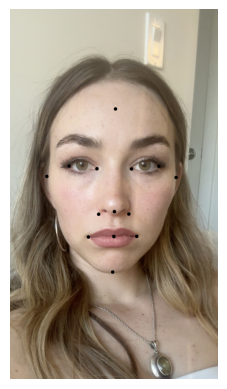

In [113]:
img = rgb_image.copy()


for i in features:

    landmark = features[i]

    print(landmark)
    # multiply normalised coordinates by width and height to get pixel coordinates that 
    # match the image
    
    # draw a circle for each coordinate
    cv.circle(
        img,
        (landmark['pixel_x'], landmark['pixel_y']),
        radius=8,
        color=(0, 0, 0),
        thickness=-1,
    )





plt.imshow(img)
plt.axis('off')


-1.0169780307191734
(1690,)
x: [469 477 475 482] y: [1201  925 1039  456]


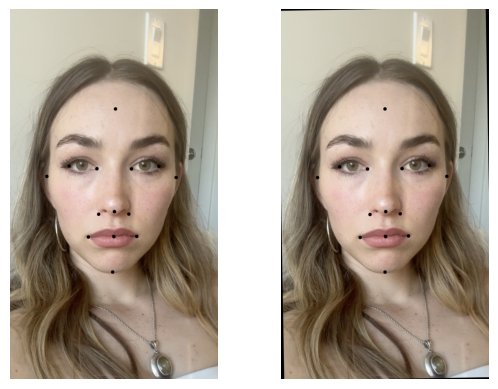

In [114]:
chin = features['chin']
chin_x= chin['pixel_x']
chin_y = chin['pixel_y']
nose = features['nose_tip']
nose_x = nose['pixel_x']
nose_y = nose['pixel_y']
upper_lip = features['upper_lip']
upper_lip_x = upper_lip['pixel_x']
upper_lip_y = upper_lip['pixel_y']
upper_face = features['upper_face']
upper_face_x = upper_face['pixel_x']
upper_face_y = upper_face['pixel_y']

x = np.array([chin_x, nose_x, upper_lip_x, upper_face_x])
y = np.array([chin_y, nose_y, upper_lip_y, upper_face_y])

a, b = np.polyfit(x, y, 1)


y0 = 0
x0 = int((y0-b)/a)

# here we find the point where this line would cross the bottom
#  of the image, i.e the height for the y value
y1 = height
x1 = int((y1 - b)/a)

# find change in x and chnage in y
delta_x = x1 - x0
delta_y = y1 - y0

# find angle that the line of best fit makes with the vertical
#  using trigonomatry
theta = np.arctan(delta_x/delta_y)
theta = np.rad2deg(theta)
print(theta)

h, w = img.shape[:2]
centre = (w/2, h/2)

rotation_matrix = cv.getRotationMatrix2D(center=centre,angle=-theta,scale=1.0,)

rotated_img = cv.warpAffine(
    img,
    rotation_matrix,
    (w, h),
    flags=cv.INTER_LINEAR,
    borderMode=cv.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)

delta_x = abs(delta_x)

#cropped_img = rotated_img[delta_x:h - delta_x, delta_x: w - delta_x]



#plt.plot(x, a*x+b)
img = cv.line(img, (2159, 0), (1917, 5712), (255, 0, 0), 15)



plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rotated_img)
plt.axis('off')
print(img.shape[:1])
print(f"x: {x}", f"y: {y}")


### Function:  run_mediapipe_extract_symmetry_points

In [55]:

def get_detection_result_takes_path(img_path:str):
    """
    Takes in an image path and runs mediapipe on image.
    
    returns detection_result
        
    """
    # make image
    bgr_image = cv.imread(img_path)
        
    if bgr_image is None:
        raise FileNotFoundError( f"opencv cant read image")
        
    rgb_image = cv.cvtColor(
        bgr_image,
        cv.COLOR_BGR2RGB,
    )
        
    rgb_image = np.ascontiguousarray(
        rgb_image,
        dtype=np.uint8,
    )
        
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image, )
        
    # detect landmarks 
    detection_result = detector.detect(mp_image)
    return detection_result




def run_mediapipe_extract_symmetry_points(detection_result, img) -> np.ndarray:
    """
    Takes in an detection result and an image returns an x array and y array
    of points along the centre of the face
    """

    # finds the first (and only in this case) face detected by detection_result
    first_face = detection_result.face_landmarks[0]

    h, w = img.shape[:2]

    # the list of features that are meant to be in the centre of the face and 
    # their index with detection_result
    FEATURES = {"nose_tip": 1, "upper_lip": 13, "upper_face": 10, "chin": 152,}

    
    x = []
    y = []

    for feature_name, landmark_index in FEATURES.items():

        # each separate point in list of face landmarks
        landmark = first_face[landmark_index]

        pixel_x =  int(landmark.x * width)
        pixel_y = int(landmark.y * height)

        x.append(pixel_x)
        y.append(pixel_y)
        
    return x, y
        
def get_angle_of_rotation(img, x, y):
    """ Takes in an image and x and y arrays and 
    returns the angle the face makes iwth the vertical
    and the change in x that the rotation would create
    """
    height, _, _ = img.shape
    # this is the line of best fit that goes through the point in 
    # the x and y array in the form y = ax + b
    a, b = np.polyfit(x, y, 1)

    # now we find points x0, y0 where the line would cross the 
    # top of the image by rearranging y = ax+b to x = (y-b)/a
    # y0 is zero at the top of the image
    y0 = 0
    x0 = int((y0-b)/a)

    # here we find the point where this line would cross the bottom
    #  of the image, i.e the height for the y value
    y1 = height
    x1 = int((y1 - b)/a)

    # find change in x and chnage in y
    delta_x = x1 - x0
    delta_y = y1 - y0

    # find angle that the line of best fit makes with the vertical
    #  using trigonomatry
    theta = np.arctan(delta_x/delta_y)

    return theta, delta_x




    

## Rotation funciton

 theta = -1.32 degrees
(1612, 873, 3)


(np.float64(-0.5), np.float64(872.5), np.float64(1611.5), np.float64(-0.5))

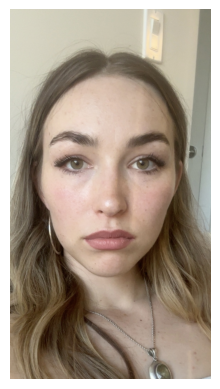

In [81]:
img_path = r'/Users/evedurant/Desktop/facemetric-api/tests/face.jpg'

def rotate_image(img, angle, delta_x) -> np.ndarray:
    """ rotates an image around its center and crops it by delta_x on all sides
    """
    h, w = img.shape[:2]
    centre = (w/2, h/2)

    rotation_matrix = cv.getRotationMatrix2D(center=centre,angle=-angle,scale=1.0,)

    rotated_img = cv.warpAffine(
        img,
        rotation_matrix,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderMode=cv.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )

    delta_x = abs(delta_x)

    cropped_img = rotated_img[delta_x:h - delta_x, delta_x: w - delta_x]
                                             

    return cropped_img


def rotate(img_path):
    """ Takes in an image path and returns a rotated image based
    on features of the face 
    """

    img = cv.imread(img_path)
    detection_result = get_detection_result_takes_path(img_path)
    x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
    theta, delta_x = get_angle_of_rotation(img, x, y)
    print(f" theta = {round(np.rad2deg(theta), 2)} degrees")
    cropped_img = rotate_image(img, theta, delta_x)
    cropped_img = cv.cvtColor(
            cropped_img,
            cv.COLOR_RGB2BGR)
    return cropped_img




#img = cv.imread(img_path)

# cv loads image in BGR but plt.imshow expects a RGB image
#img = cv.cvtColor(img, cv.COLOR_BGR2RGB)




rotated_img = rotate(img_path)

print(rotated_img.shape)
plt.imshow(rotated_img)
plt.axis('off')


In [316]:
y = img.shape[0]
x = (y-b)/a

print(x)


502.6263622210686


### ChatGPT use:
I used ai here to debug this function. It explained that openCV, pillow and mediapipe all exoect different arrays OoenCV expects a BGR image and Mediapipe expects an RGB image and so chat helped me develop the steps here.

In [104]:
def get_detection_result_takes_img(img):
    """
    Takes in an image path and runs mediapipe on image.
    
    returns detection_result
        
    """
    # make image
    bgr_image = img
        
    if bgr_image is None:
        raise FileNotFoundError( f"opencv cant read image")


    # used chatGPT for this function to understand why the image was coming out blue
    # there was a mismatch with the rgb and bgr arrays
    rgb_image = cv.cvtColor(
        bgr_image,
        cv.COLOR_BGR2RGB,
    )
        
    rgb_image = np.ascontiguousarray(
        rgb_image,
        dtype=np.uint8,
    )

    print("type:", type(rotated_img))
    print("shape:", rotated_img.shape)
    print("dtype:", rotated_img.dtype)
    print("min:", rotated_img.min())
    print("max:", rotated_img.max())
        
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image, )
        
    # detect landmarks 
    detection_result = detector.detect(mp_image)
    return detection_result



type: <class 'numpy.ndarray'>
shape: (1690, 951, 3)
dtype: uint8
min: 0
max: 255
FaceLandmarkerResult(face_landmarks=[[NormalizedLandmark(x=0.5039776563644409, y=0.5968528985977173, z=-0.07025118917226791, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.503074586391449, y=0.5455871224403381, z=-0.14724498987197876, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.501794695854187, y=0.5608847141265869, z=-0.0724320337176323, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4777160882949829, y=0.4864215850830078, z=-0.1188138797879219, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5031346678733826, y=0.5286222696304321, z=-0.15931594371795654, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5026835203170776, y=0.5046186447143555, z=-0.15097472071647644, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5019233822822571, y=0.4431488513946533, z=-0.08279889822006226, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.29395195841789246, y=0.4324637651443

(np.float64(-0.5), np.float64(950.5), np.float64(1689.5), np.float64(-0.5))

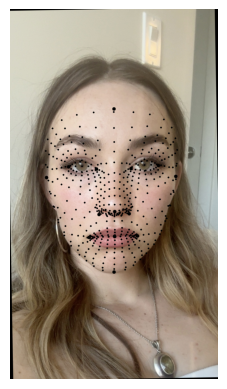

In [105]:
detection_result = get_detection_result_takes_img(rotated_img)

print(detection_result)

def draw_points_on_img(detection_result, img):
    # make image

    h, w, _ = img.shape

    # this finds a suitable radius for the printed points depending on 
    # the size of the image
    radius = int( h/380)


    
    annotated_image = draw_landmarks( 
        img,
        detection_result, radius
    )
    return annotated_image


annotated_img = draw_points_on_img(detection_result, rotated_img)

plt.imshow(annotated_img)
plt.axis('off')

In [59]:
print(detection_result)
face = detection_result.face_landmarks[0]
left_eye_outer = face[33]
left_eye_outer = [left_eye_outer.x, left_eye_outer.y]

left_eye_inner = face[133]
left_eye_inner = [left_eye_inner.x, left_eye_inner.y]
delta_x_left = left_eye_inner[0] - left_eye_outer[0]
delta_y_left = left_eye_inner[1] - left_eye_outer[1]

right_eye_outer = face[263]
right_eye_outer = [right_eye_outer.x, right_eye_outer.y]

right_eye_inner = face[362]
right_eye_inner = [right_eye_inner.x, right_eye_inner.y]

theta = np.arctan(delta_y_left/delta_x_left)
theta = np.rad2deg(theta)

delta_x_right = right_eye_outer[0] - right_eye_inner[0]
delta_y_right = right_eye_inner[1] - right_eye_outer[1]

theta_right = np.arctan(delta_y_right/delta_x_right)
theta_right = np.rad2deg(theta_right)

inter_eye_distance = right_eye_inner[0]-left_eye_inner[0]
print(f" inter eye distance: {inter_eye_distance}")

print(f"left eye size: {delta_x_left}")

print(theta_right)

FaceLandmarkerResult(face_landmarks=[[NormalizedLandmark(x=0.47466716170310974, y=0.6218420267105103, z=-0.061414770781993866, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4783842861652374, y=0.5496078133583069, z=-0.13076142966747284, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47453299164772034, y=0.5650713443756104, z=-0.06716947257518768, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.45495712757110596, y=0.4879482388496399, z=-0.10305377840995789, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.479601114988327, y=0.5323337316513062, z=-0.13995401561260223, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47932562232017517, y=0.5078799724578857, z=-0.13191720843315125, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4771842956542969, y=0.4447924792766571, z=-0.06971955299377441, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.3014875650405884, y=0.4268891215324402, z=0.0194415096193552, visibility=0.0, presence=0.0), NormalizedLandma

### Canthal tilt and eye distnace

[0.29082632064819336, 0.4248295724391937]
[0.3972909450531006, 0.42495986819267273]
[0.5440312027931213, 0.42930108308792114]
[0.644741415977478, 0.43332770466804504]


(np.float64(-0.5), np.float64(3799.5), np.float64(5227.5), np.float64(-0.5))

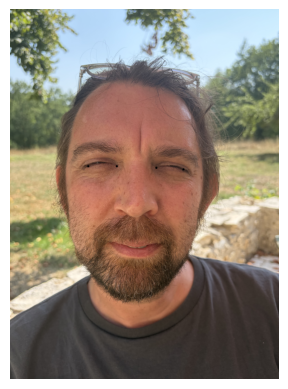

In [61]:
features = [left_eye_outer, left_eye_inner, right_eye_inner, right_eye_outer]
img = rotated_img.copy()

h, w, _ = img.shape

for landmark in features:

    x, y = landmark
    normalised_x = x * w
    normalised_y = y * h

    print(landmark)
    # multiply normalised coordinates by width and height to get pixel coordinates that 
    # match the image
    
    # draw a circle for each coordinate
    cv.circle(
        img,
        (int(normalised_x), int(normalised_y)),
        radius=15,
        color=(0, 0, 0),
        thickness=-1,
    )


plt.imshow(img)
plt.axis('off')

### Function for canthal tilt (also want to add inter eye distance)

perhaps i can break this down into separate functions

In [62]:
def canthal_tilt(detection_result, img) -> np.ndarray:
    """
    takes in a detection result and determines the canthal tilt of left eye, right eye
    """

    # finds the first (and only in this case) face detected by detection_result
    face = detection_result.face_landmarks[0]

    

    EYE_INDICES = {
    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "right_eye_inner": 362,
    "right_eye_outer": 263,}

    # get left eye outer point information from its index
    left_eye_outer = face[33]
    left_eye_outer = [left_eye_outer.x, left_eye_outer.y]

    # get left eye inner point information from its index
    left_eye_inner = face[133]
    left_eye_inner = [left_eye_inner.x, left_eye_inner.y]


    # keeping positive tilt positive

    # subtract the outer left x value from the inner one (this will always be positive)
    delta_x_left = left_eye_inner[0] - left_eye_outer[0]

    # subtract outer left y value from the inner one (will be positive if canthal tilt is positive) 
    delta_y_left = left_eye_inner[1] - left_eye_outer[1]


    theta_left = np.arctan(delta_y_left/delta_x_left)
    theta_left = float(np.rad2deg(theta_left))



    right_eye_outer = face[263]
    right_eye_outer = [right_eye_outer.x, right_eye_outer.y]

    right_eye_inner = face[362]
    right_eye_inner = [right_eye_inner.x, right_eye_inner.y]


    delta_x_right = right_eye_outer[0] - right_eye_inner[0]
    delta_y_right = right_eye_inner[1] - right_eye_outer[1]

    theta_right = np.arctan(delta_y_right/delta_x_right)
    theta_right = float(np.rad2deg(theta_right))

    
   

    return theta_left, theta_right

In [63]:
canthal_tilt(detection_result, img)

(0.07012087890570134, -2.28959504077051)

In [64]:
KEY_FEATURE_INDICES = {
    "nose_bottom": 2,

    "upper_lip_top": 0,
    "lower_lip_bottom": 17,
    "mouth_left": 61,
    "mouth_right": 291,
    "upper_lip": 13,

    "right_brow_start": 107,
    "right_brow_arch": 105,
    "right_brow_end": 70,

    "intrabrow_bottom": 8,

    "left_brow_start": 336,
    "left_brow_arch": 334,
    "left_brow_end": 300,

    "right_nostril_outer": 98,
    "left_nostril_outer": 327,

    "chin": 152,
    "left_cheek": 234,
    "right_cheek": 454,

    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "right_eye_inner": 362,
    "right_eye_outer": 263,

    "left_iris_outer": 471,
    "left_iris_inner": 469,

    "right_iris_inner": 476,
    "right_iris_outer": 474,
}

In [243]:
KEY_FEATURE_INDICES["upper_lip"]

13

## ChatGPT functions - for visualisation

In [65]:
def extract_key_features(
    detection_result,
    image_width: int,
    image_height: int,
):
    if not detection_result.face_landmarks:
        return {}

    face_landmarks = detection_result.face_landmarks[0]
    features = {}

    for feature_name, index in KEY_FEATURE_INDICES.items():
        landmark = face_landmarks[index]

        features[feature_name] = {
            "index": index,
            "normalized_x": landmark.x,
            "normalized_y": landmark.y,
            "normalized_z": landmark.z,
            "pixel_x": round(landmark.x * image_width),
            "pixel_y": round(landmark.y * image_height),
        }

    return features

In [66]:
def draw_key_features(
    rgb_image: np.ndarray,
    detection_result,
) -> np.ndarray:
    annotated_image = rgb_image.copy()
    height, width, _ = annotated_image.shape

    features = extract_key_features(
        detection_result,
        image_width=width,
        image_height=height,
    )

    for name, point in features.items():
        x = int(point["pixel_x"])
        y = int(point["pixel_y"])

        cv.circle(
            annotated_image,
            (x, y),
            radius=14,
            color=(0, 0, 0),
            thickness=-1,
        )


    return annotated_image

(np.float64(-0.5), np.float64(3799.5), np.float64(5227.5), np.float64(-0.5))

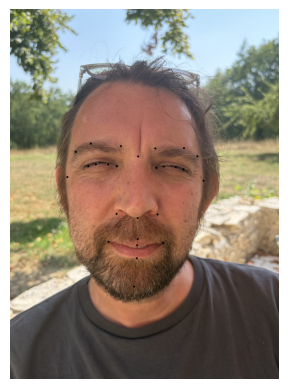

In [71]:

annotated_img = draw_key_features(img, detection_result)


plt.imshow(annotated_img)
plt.axis('off')



In [72]:
def top_bottom_lip_ratio(detection_result):
    """ Takes in a detection result and returns the ratio
    between the height of the toip and bottom lip
    """
    face = detection_result.face_landmarks[0]

    # returns the index key associated with the point at top of upper lip
    upper_lip_index = KEY_FEATURE_INDICES["upper_lip_top"]
    upper_lip = face[upper_lip_index]
    upper_lip_y = upper_lip.y

    
    lower_lip_index = KEY_FEATURE_INDICES["lower_lip_bottom"]
    lower_lip = face[lower_lip_index]
    lower_lip_y = lower_lip.y


    middle_index = KEY_FEATURE_INDICES["upper_lip"]
    middle = face[middle_index]
    middle_y = middle.y


    top_lip_height = middle_y - upper_lip_y

    lower_lip_height = lower_lip_y - middle_y


    return lower_lip_height/top_lip_height


    

In [69]:
lip_ratio = top_bottom_lip_ratio(detection_result)
print(f" the bottom lip is {lip_ratio} times as large as the top lip. The ideal is 1.6 ")

 the bottom lip is 2.0895340744838418 times as large as the top lip. The ideal is 1.6 


In [73]:
def bottom_two_thirds(detection_result):
    """ 
    Takes in a detection result and determines
    the ratio between the lower two "thirds" of the face.

    Returns the middle third divided by the bottom third
    """
    intrabrow_bottom_index = KEY_FEATURE_INDICES["intrabrow_bottom"]
    intrabrow = face[intrabrow_bottom_index]
    intrabrow_y = intrabrow.y
    
        
    nose_bottom_index = KEY_FEATURE_INDICES["nose_bottom"]
    nose_bottom = face[nose_bottom_index]
    nose_bottom_y = nose_bottom.y
    

    
    
    chin_index = KEY_FEATURE_INDICES["chin"]
    chin = face[chin_index]
    chin_y = chin.y

    
    middle_third = nose_bottom_y - intrabrow_y
    
    bottom_third = chin_y - nose_bottom_y
    
    
    return middle_third/bottom_third

bottom_thirds_ratio = bottom_two_thirds(detection_result)
print(f" the middle third is {bottom_thirds_ratio} times as large as the bottom third. The ideal is roughly {1/0.9}. You deviate by.... ")

 the middle third is 0.9013936355858055 times as large as the bottom third. The ideal is roughly 1.1111111111111112. You deviate by.... 


In [74]:
def nose_to_chin(detection_result):
    """Takes in a detection result and returns the ratio between the 
    nose to the bottom of the lips and the bottom of the lips to the chin. This should be roughly 1
    """
    nose_bottom_index = KEY_FEATURE_INDICES["nose_bottom"]
    nose_bottom = face[nose_bottom_index]
    nose_bottom_y = nose_bottom.y

    lower_lip_index = KEY_FEATURE_INDICES["lower_lip_bottom"]
    lower_lip = face[lower_lip_index]
    lower_lip_y = lower_lip.y
    
     
        
    chin_index = KEY_FEATURE_INDICES["chin"]
    chin = face[chin_index]
    chin_y = chin.y
    
        
    nose_to_lip_bottom = lower_lip_y - nose_bottom_y
        
    lip_bottom_to_chin = chin_y - lower_lip_y
        
        
    return nose_to_lip_bottom/lip_bottom_to_chin

nose_to_chin_ratio = nose_to_chin(detection_result)
print(f" the ratio between the nose to the bottom of the lips and the bottom of the lips to the chin is {nose_to_chin_ratio}. It should be 1")

 the ratio between the nose to the bottom of the lips and the bottom of the lips to the chin is 1.414984251803046. It should be 1


In [275]:
def arch_symmetry(detection_result):
    """ Takes in a detection result and returns the 
    x distance each brow arch is from the centre
    """

    right_arch_index = KEY_FEATURE_INDICES["right_brow_arch"]
    right_arch = face[right_arch_index]
    right_arch_x = right_arch.x
    print(f"right arch : {right_arch_x}")

    intrabrow_bottom_index = KEY_FEATURE_INDICES["intrabrow_bottom"]
    intrabrow = face[intrabrow_bottom_index]
    intrabrow_x = intrabrow.x
    print(intrabrow_x) 
    
    left_arch_index = KEY_FEATURE_INDICES["left_brow_arch"]
    left_arch = face[left_arch_index]
    left_arch_x = left_arch.x
    print(left_arch_x)

    left_width = intrabrow_x - left_arch_x
    right_width = right_arch_x - intrabrow_x

    return left_width, right_width 

left, right = arch_symmetry(detection_result)
print(f"the horizontal distance form the centre to the left brow arch is {left} and to the right brow arch is {right}")
    
    

right arch : 0.27643293142318726
0.5041967630386353
0.728584349155426
the horizontal distance form the centre to the left brow arch is -0.22438758611679077 and to the right brow arch is -0.227763831615448
